In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("outputs/clip1_30s_tracks.csv")
df.head()

car = df[df.track_id == 4].sort_values("time_s")

#Computing time to collision
car["w_smooth"] = car["w"].rolling(15, center=True).mean()

# Growth rate in pixels per second
car["dw_dt"] = np.gradient(car["w_smooth"], car["time_s"])

# TTC only means something when the box is growing (we're closing)
car["ttc"] = np.where(car["dw_dt"] > 0, car["w_smooth"] / car["dw_dt"], np.nan)


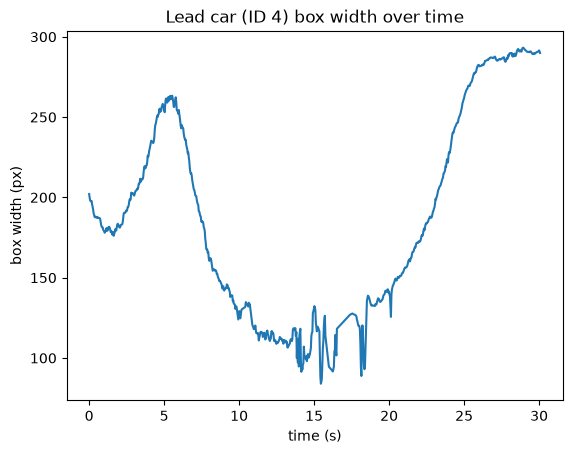

In [4]:
plt.plot(car["time_s"], car["w"])
plt.xlabel("time (s)")
plt.ylabel("box width (px)")
plt.title("Lead car (ID 4) box width over time")
plt.show()


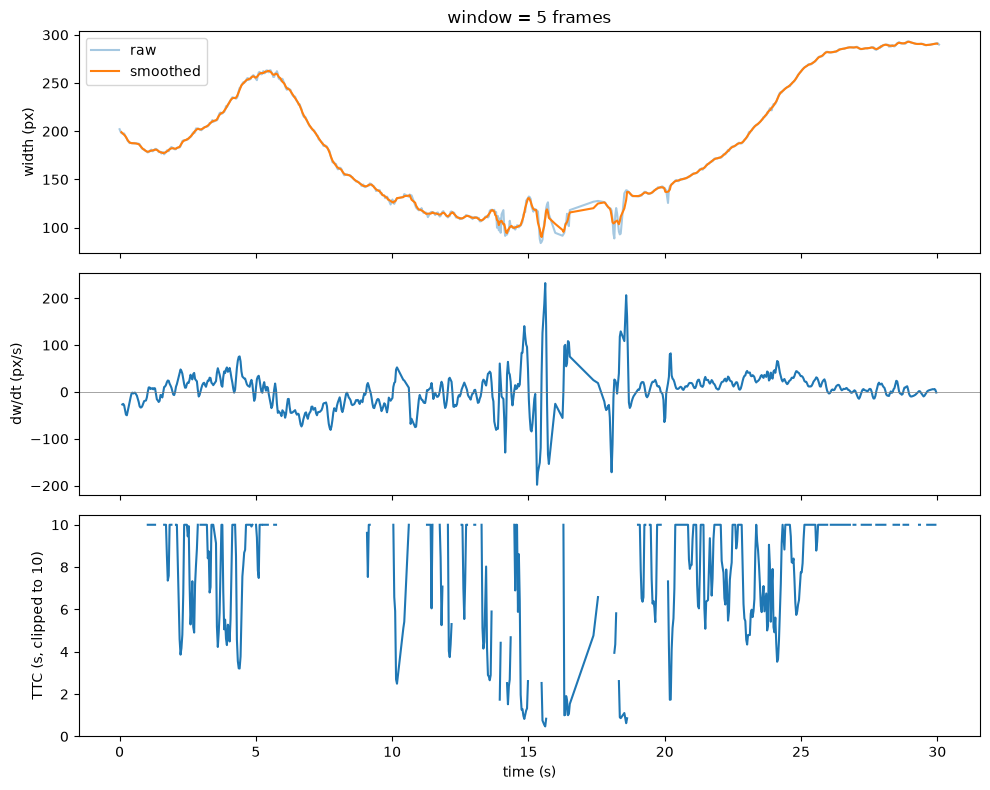

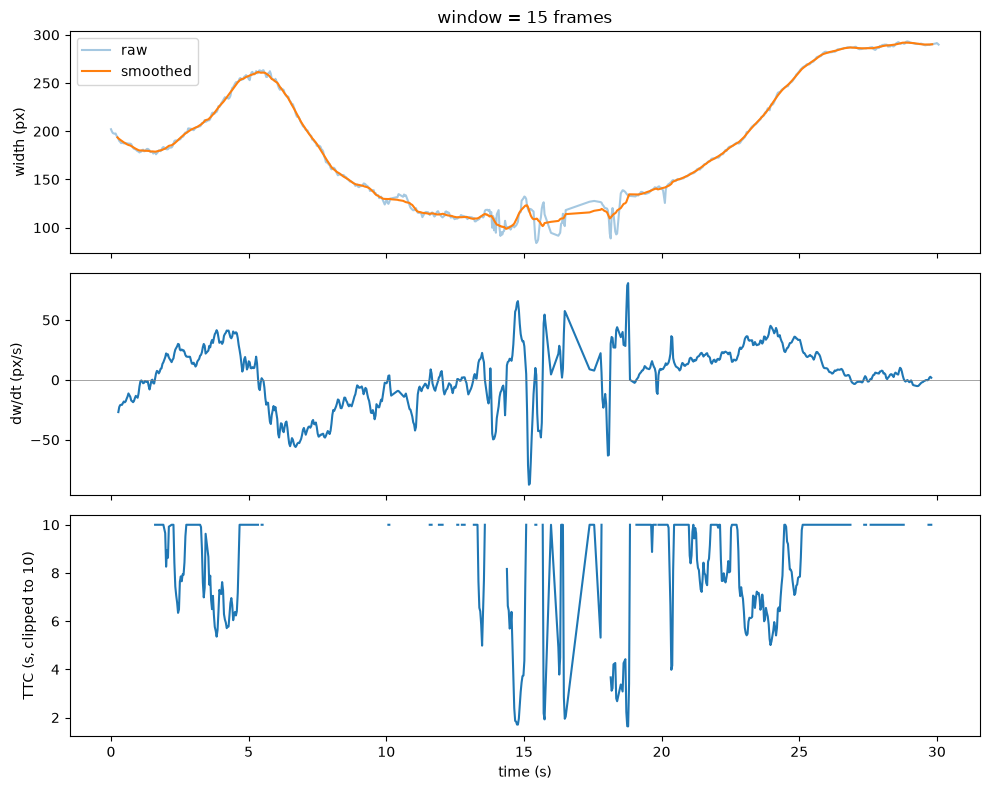

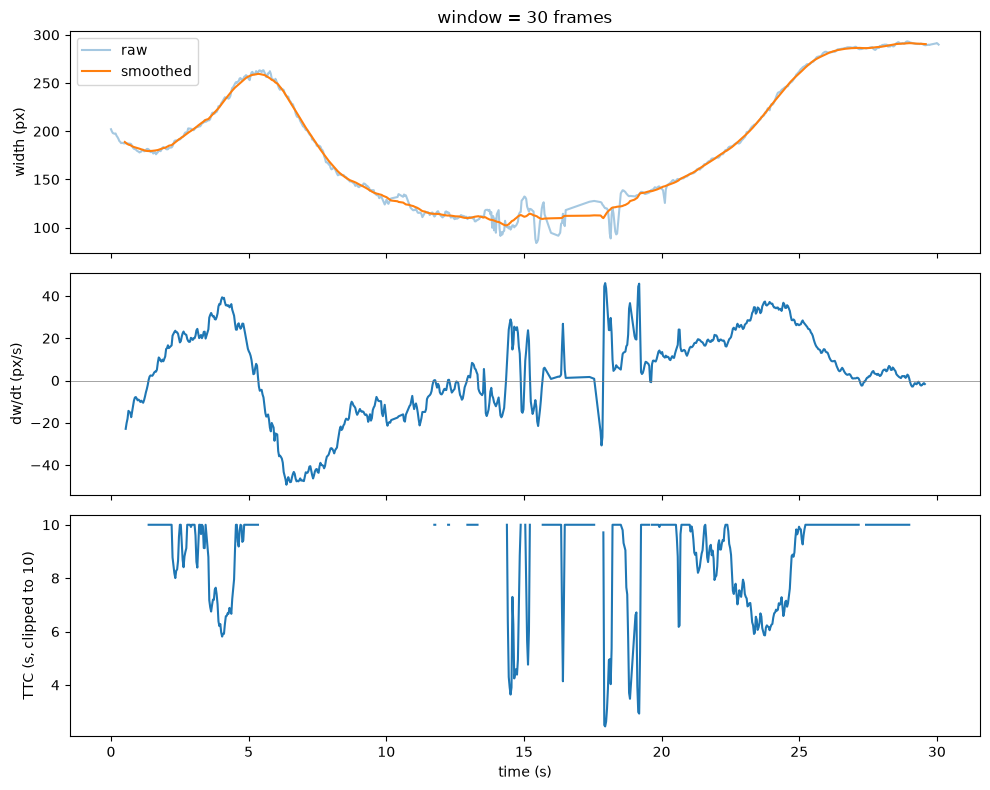

In [3]:
def plot_ttc(car, window):
    c = car.copy()
    c["w_smooth"] = c["w"].rolling(window, center=True).mean()
    c["dw_dt"] = np.gradient(c["w_smooth"], c["time_s"])
    c["ttc"] = np.where(c["dw_dt"] > 0, c["w_smooth"] / c["dw_dt"], np.nan)

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    axes[0].plot(c["time_s"], c["w"], alpha=0.4, label="raw")
    axes[0].plot(c["time_s"], c["w_smooth"], label="smoothed")
    axes[0].set_ylabel("width (px)")
    axes[0].legend()
    axes[0].set_title(f"window = {window} frames")

    axes[1].plot(c["time_s"], c["dw_dt"])
    axes[1].axhline(0, color="gray", linewidth=0.5)
    axes[1].set_ylabel("dw/dt (px/s)")

    axes[2].plot(c["time_s"], c["ttc"].clip(upper=10))
    axes[2].set_ylabel("TTC (s, clipped to 10)")
    axes[2].set_xlabel("time (s)")

    plt.tight_layout()
    plt.show()
    return c

for window in (5, 15, 30):
    plot_ttc(car, window)


In [4]:
# Diagnostic: is this track continuous, or does it have gaps where the
# detector missed the car for a few frames?
frame_gaps = car["frame"].diff()
print("Frame count:", len(car))
print("Frame span:", car["frame"].max() - car["frame"].min() + 1)
print("Gaps > 1 frame:", (frame_gaps > 1).sum())
print(frame_gaps.value_counts().sort_index())


Frame count: 812
Frame span: 902
Gaps > 1 frame: 29
frame
1.0     782
2.0      16
3.0       3
4.0       2
5.0       3
7.0       3
8.0       1
26.0      1
Name: count, dtype: int64


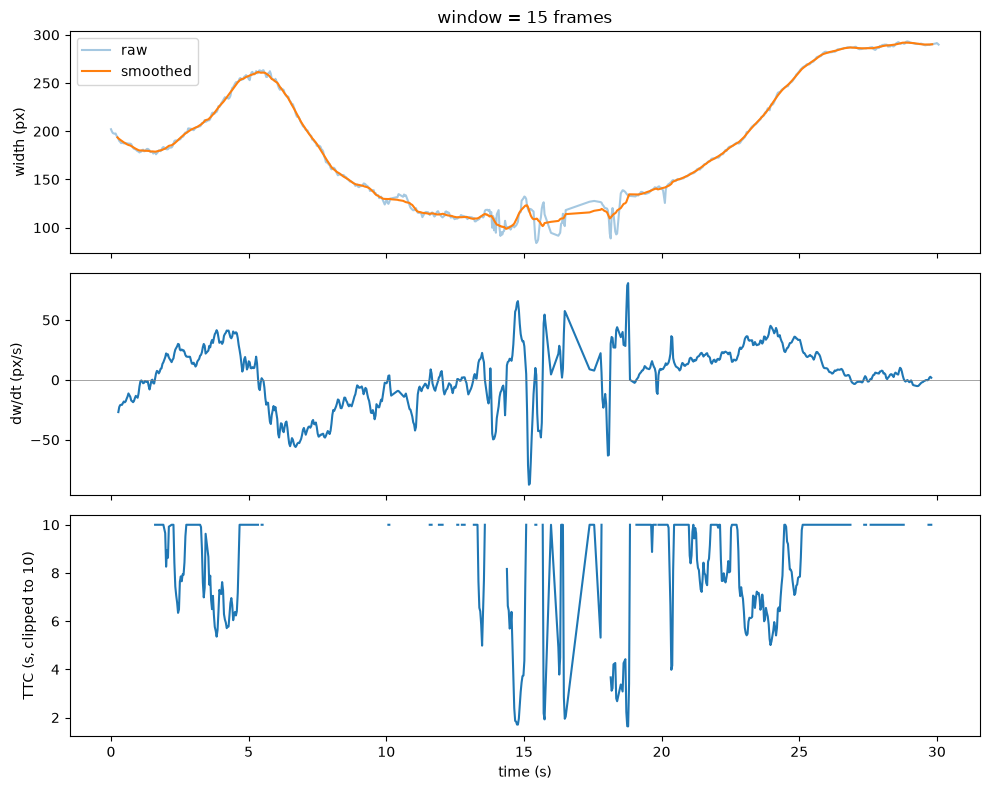

dw_dt sign flips: 54 over 812 frames
Fraction of frames with dw_dt near zero (|dw_dt| < 5 px/s): 0.18226600985221675
Fraction of frames with usable (non-nan) TTC: 0.5825123152709359


In [5]:
# Diagnostic: how often does dw_dt flip sign (steady-state noise), and
# what fraction of the track has usable (non-nan) TTC?
c = plot_ttc(car, 15)  # reuse the window=15 computation from the function

sign = np.sign(c["dw_dt"])
sign_flips = (sign.diff() != 0).sum()
print("dw_dt sign flips:", sign_flips, "over", len(c), "frames")
print("Fraction of frames with dw_dt near zero (|dw_dt| < 5 px/s):",
      (c["dw_dt"].abs() < 5).mean())
print("Fraction of frames with usable (non-nan) TTC:", c["ttc"].notna().mean())


In [6]:
# --- Kalman filter, step 1: state ---
#
# The filter tracks two numbers ("the state") at every frame:
#   x[0] = width estimate (px)
#   x[1] = rate estimate, i.e. dw/dt (px/s)
#
# We also track how *uncertain* we are about that state, as a 2x2
# covariance matrix P. Big P = "I don't trust this estimate yet."
# Initialize width to the first real measurement, rate to 0 (no
# information yet), and uncertainty high since we're just guessing.

widths = car["w"].to_numpy()
times = car["time_s"].to_numpy()

x = np.array([widths[0], 0.0])   # initial state: [width, rate]
P = np.eye(2) * 100.0            # initial uncertainty: fairly unsure

print("Initial state (width, rate):", x)
print("Initial uncertainty:\n", P)


Initial state (width, rate): [202.1   0. ]
Initial uncertainty:
 [[100.   0.]
 [  0. 100.]]


In [7]:
# --- Kalman filter, step 2: predict (just once, for frame 0 -> frame 1) ---
#
# F: "constant velocity" model.
#   new_width = width + rate * dt
#   new_rate  = rate                (we assume rate stays the same;
#                                     Q below is how much we allow it to drift)
#
# Q: process noise. We scale it by dt because the longer we go without a
# measurement (e.g. during a frame gap), the more the true rate could have
# drifted, so we should trust our own prediction less over larger gaps.

dt = times[1] - times[0]

F = np.array([[1.0, dt],
              [0.0, 1.0]])

q_width = 1.0   # how much width itself can drift unexplained, per second
q_rate = 50.0   # how much the rate can drift unexplained, per second (this one matters more)
Q = np.array([[q_width * dt, 0.0],
              [0.0,          q_rate * dt]])

x_pred = F @ x
P_pred = F @ P @ F.T + Q

print("dt:", dt)
print("Predicted state (width, rate):", x_pred)
print("Predicted uncertainty:\n", P_pred)


dt: 0.033
Predicted state (width, rate): [202.1   0. ]
Predicted uncertainty:
 [[100.1419   3.3   ]
 [  3.3    101.65  ]]


In [8]:
# --- Kalman filter, step 3: update (fold in the frame-1 measurement) ---
#
# H picks width out of the state [width, rate] -> we can only measure width.
# R is measurement noise: how much we expect a single box-width reading to
# jitter due to detector noise, independent of the car's real motion.

H = np.array([[1.0, 0.0]])
R = np.array([[25.0]])   # px^2 -- e.g. +-5px typical jitter

z = widths[1]                        # the new measurement
y = z - (H @ x_pred)[0]              # innovation: measured - predicted
S = (H @ P_pred @ H.T)[0, 0] + R[0, 0]   # innovation covariance
K = (P_pred @ H.T).flatten() / S     # Kalman gain (one weight per state var)

x_new = x_pred + K * y
P_new = (np.eye(2) - np.outer(K, H)) @ P_pred

print("Measurement:", z)
print("Innovation (measured - predicted):", y)
print("Kalman gain:", K)
print("Updated state (width, rate):", x_new)
print("Updated uncertainty:\n", P_new)


Measurement: 199.8
Innovation (measured - predicted): -2.299999999999983
Kalman gain: [0.80022678 0.02637006]
Updated state (width, rate): [ 2.00259478e+02 -6.06511488e-02]
Updated uncertainty:
 [[ 20.00566956   0.65925162]
 [  0.65925162 101.56297879]]


In [10]:
# --- Kalman filter, step 4: run it over the whole track ---
#
# Same predict + update math as above, just looped frame by frame, storing
# the state at every step. Reset x, P fresh (the cells above already
# advanced them by one step, we don't want to double-apply that).

x = np.array([widths[0], 0.0])
P = np.eye(2) * 100.0

n = len(widths)
w_kalman = np.zeros(n)
rate_kalman = np.zeros(n)
w_kalman[0], rate_kalman[0] = x

for i in range(1, n):
    dt = times[i] - times[i - 1]
    if dt <= 0:
        dt = 1 / 30  # guard against duplicate/out-of-order timestamps

    F = np.array([[1.0, dt],
                  [0.0, 1.0]])
    Q = np.array([[q_width * dt, 0.0],
                  [0.0,          q_rate * dt]])

    # predict
    x = F @ x
    P = F @ P @ F.T + Q

    # update
    z = widths[i]
    y = z - (H @ x)[0]
    S = (H @ P @ H.T)[0, 0] + R[0, 0]
    K = (P @ H.T).flatten() / S

    x = x + K * y
    P = (np.eye(2) - np.outer(K, H)) @ P

    w_kalman[i], rate_kalman[i] = x

car["w_kalman"] = w_kalman
car["rate_kalman"] = rate_kalman

# np.where evaluates w_kalman/rate_kalman everywhere (even where rate<=0),
# so divide-by-zero there is expected -- use np.divide's `where` so it only
# actually computes the division where it's valid, no warning.
ttc_kalman = np.full(n, np.nan)
np.divide(w_kalman, rate_kalman, out=ttc_kalman, where=rate_kalman > 0)
car["ttc_kalman"] = ttc_kalman

print("Kalman: dw/dt sign flips:", (np.sign(rate_kalman[1:]) != np.sign(rate_kalman[:-1])).sum())
print("Kalman: fraction non-nan TTC:", car["ttc_kalman"].notna().mean())


Kalman: dw/dt sign flips: 15
Kalman: fraction non-nan TTC: 0.5763546798029556


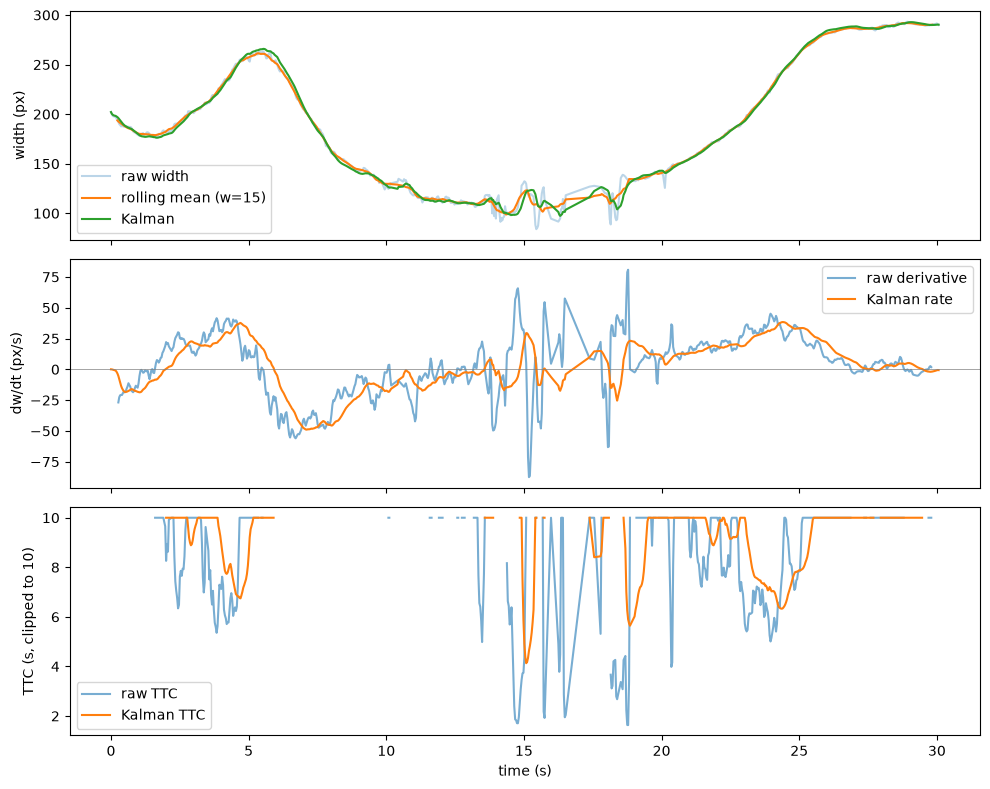

In [11]:
# --- Compare: raw rolling-mean derivative (window=15) vs. Kalman ---
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(car["time_s"], car["w"], alpha=0.3, label="raw width")
axes[0].plot(car["time_s"], car["w_smooth"], label="rolling mean (w=15)")
axes[0].plot(car["time_s"], car["w_kalman"], label="Kalman")
axes[0].set_ylabel("width (px)")
axes[0].legend()

axes[1].plot(car["time_s"], car["dw_dt"], alpha=0.6, label="raw derivative")
axes[1].plot(car["time_s"], car["rate_kalman"], label="Kalman rate")
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].set_ylabel("dw/dt (px/s)")
axes[1].legend()

axes[2].plot(car["time_s"], car["ttc"].clip(upper=10), alpha=0.6, label="raw TTC")
axes[2].plot(car["time_s"], car["ttc_kalman"].clip(upper=10), label="Kalman TTC")
axes[2].set_ylabel("TTC (s, clipped to 10)")
axes[2].set_xlabel("time (s)")
axes[2].legend()

plt.tight_layout()
plt.show()


current: sign flips=15, non-nan TTC frac=0.576
tighter: sign flips=10, non-nan TTC frac=0.611


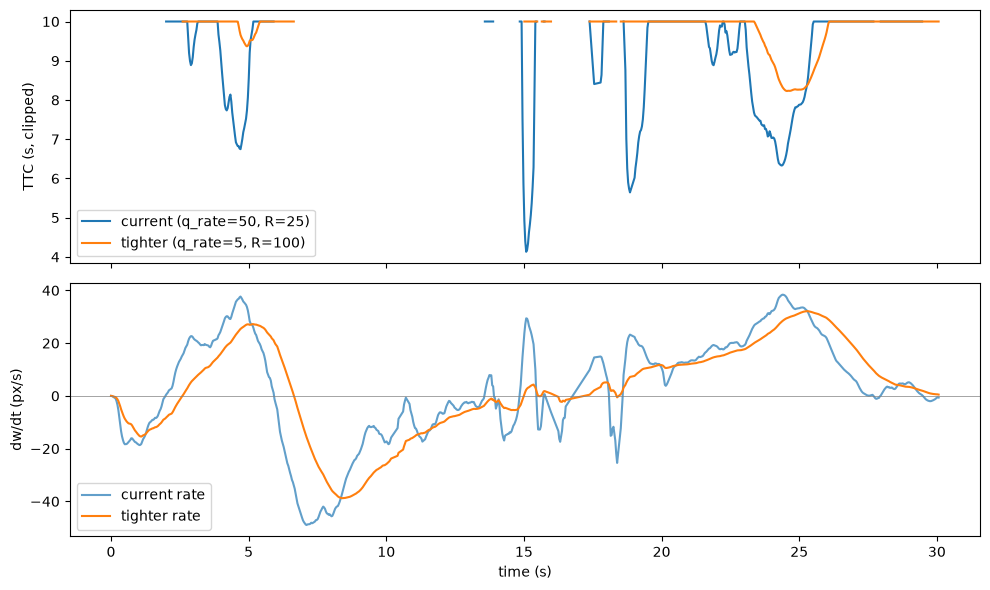

In [12]:
# --- Kalman filter, step 5: tune Q vs R and compare ---
#
# Wrap the loop as a function so we can try different (q_width, q_rate, r_meas)
# without copy-pasting the loop. Lower q_rate = trust momentum more (smoother,
# slower to react). Higher R = trust each individual measurement less.

def run_kalman(widths, times, q_width, q_rate, r_meas):
    x = np.array([widths[0], 0.0])
    P = np.eye(2) * 100.0
    H = np.array([[1.0, 0.0]])
    R = np.array([[r_meas]])
    n = len(widths)
    w_k = np.zeros(n)
    rate_k = np.zeros(n)
    w_k[0], rate_k[0] = x

    for i in range(1, n):
        dt = times[i] - times[i - 1]
        if dt <= 0:
            dt = 1 / 30
        F = np.array([[1.0, dt], [0.0, 1.0]])
        Q = np.array([[q_width * dt, 0.0], [0.0, q_rate * dt]])

        x = F @ x
        P = F @ P @ F.T + Q

        z = widths[i]
        y = z - (H @ x)[0]
        S = (H @ P @ H.T)[0, 0] + R[0, 0]
        K = (P @ H.T).flatten() / S

        x = x + K * y
        P = (np.eye(2) - np.outer(K, H)) @ P
        w_k[i], rate_k[i] = x

    ttc = np.full(n, np.nan)
    np.divide(w_k, rate_k, out=ttc, where=rate_k > 0)
    return w_k, rate_k, ttc


# Current vs a tighter tuning (less process noise on rate, more measurement noise)
w_k1, rate_k1, ttc_k1 = run_kalman(widths, times, q_width=1.0, q_rate=50.0, r_meas=25.0)
w_k2, rate_k2, ttc_k2 = run_kalman(widths, times, q_width=1.0, q_rate=5.0, r_meas=100.0)

for label, rate_k, ttc in [("current", rate_k1, ttc_k1), ("tighter", rate_k2, ttc_k2)]:
    flips = (np.sign(rate_k[1:]) != np.sign(rate_k[:-1])).sum()
    print(f"{label}: sign flips={flips}, non-nan TTC frac={np.mean(~np.isnan(ttc)):.3f}")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(times, np.clip(ttc_k1, 0, 10), label="current (q_rate=50, R=25)")
axes[0].plot(times, np.clip(ttc_k2, 0, 10), label="tighter (q_rate=5, R=100)")
axes[0].set_ylabel("TTC (s, clipped)")
axes[0].legend()

axes[1].plot(times, rate_k1, alpha=0.7, label="current rate")
axes[1].plot(times, rate_k2, label="tighter rate")
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].set_ylabel("dw/dt (px/s)")
axes[1].set_xlabel("time (s)")
axes[1].legend()

plt.tight_layout()
plt.show()


In [13]:
# --- Step 6: find where TTC actually dips, to check against reality ---
#
# Group consecutive low-TTC frames into "events" (rather than just listing
# every frame below the threshold) so we get a handful of readable time
# ranges to compare against what you remember watching in the video.

THRESH = 8.0  # seconds -- "meaningfully closing" cutoff, adjust if too noisy/sparse

is_close = car["ttc_kalman"] < THRESH
event_id = (is_close != is_close.shift()).cumsum()

events = (
    car[is_close]
    .groupby(event_id[is_close])["time_s"]
    .agg(["min", "max", "count"])
    .rename(columns={"min": "start_s", "max": "end_s", "count": "n_frames"})
)

print(f"TTC dip events (TTC < {THRESH}s, current tuning):")
print(events.round(2))


TTC dip events (TTC < 8.0s, current tuning):
            start_s  end_s  n_frames
ttc_kalman                          
2              4.14   4.27         5
4              4.37   4.94        18
6             14.95  15.35        13
8             18.72  19.35        16
10            23.29  25.16        57
